In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import os

In [4]:
# --- 1. Funciones de utilidad (Necesarias para la preparación del DF) ---

# Replicamos las funciones esenciales para asegurar la ejecución del pipeline completo.
def agregar_lags(df, columna, lags):
    for lag in lags:
        df[f'lag_{lag}'] = df[columna].shift(lag)
    return df

def agregar_medias_moviles(df, columna, ventanas):
    for ventana in ventanas:
        df[f'media_movil_{ventana}'] = df[columna].shift(1).rolling(window=ventana, min_periods=1).mean()
    return df

def agregar_variables_ciclicas(df, columna_mes, columna_fecha):
    df['mes_sin'] = np.sin(2 * np.pi * df[columna_mes] / 12)
    df['mes_cos'] = np.cos(2 * np.pi * df[columna_mes] / 12)
    df['dia_semana_sin'] = np.sin(2 * np.pi * pd.to_datetime(df[columna_fecha]).dt.weekday / 7)
    df['dia_semana_cos'] = np.cos(2 * np.pi * pd.to_datetime(df[columna_fecha]).dt.weekday / 7)
    return df

def agregar_ewma(df, columna, spans):
    for span in spans:
        df[f'ewma_{span}'] = df[columna].shift(1).ewm(span=span, adjust=False).mean()
    return df

def obtener_semestre(mes):
    if 3 <= mes <= 7:
        return 1
    elif 8 <= mes <= 12:
        return 2
    else:
        return 0

def semana_en_semestre(row):
    if row['Semestre'] == 1:
        inicio = pd.Timestamp(year=row['Año'], month=3, day=1)
    elif row['Semestre'] == 2:
        inicio = pd.Timestamp(year=row['Año'], month=8, day=1)
    else:
        return np.nan
    return ((row['Fecha'] - inicio).days // 7) + 1

In [5]:
# --- 2. Preparación y División de Datos (Exógenas y Target) ---

try:
    daily_counts_full = pd.read_csv("Datasets/daily_counts_full.csv")
    print("Dataset cargado desde 'Datasets/daily_counts_full.csv'")
except FileNotFoundError:
    print("ERROR: No se encontró el archivo 'daily_counts_full.csv'.")
    exit(1)

# A. Feature Engineering (Repetimos los pasos para un DF limpio)
for col in ['Accesos']:
    daily_counts_full[col] = daily_counts_full[col].fillna(0).astype(int)
daily_counts_full['Fecha'] = pd.to_datetime(daily_counts_full['Fecha'])
daily_counts_full = daily_counts_full[
    daily_counts_full['Fecha'].dt.weekday != 6 
].reset_index(drop=True)

daily_counts_full = agregar_medias_moviles(daily_counts_full, 'Accesos', [7, 14, 30])
daily_counts_full = agregar_variables_ciclicas(daily_counts_full, 'Mes', 'Fecha')
daily_counts_full = agregar_ewma(daily_counts_full, 'Accesos', [7, 14, 30])
daily_counts_full['Semestre'] = daily_counts_full['Mes'].apply(obtener_semestre)
daily_counts_full['Semana_Semestre'] = daily_counts_full.apply(semana_en_semestre, axis=1)
daily_counts_full['Semana_Certamen'] = daily_counts_full['Semana_Semestre'].isin([6, 7]).astype(int)
daily_counts_full = agregar_lags(daily_counts_full, 'Accesos', [7, 14, 21])

# B. Definición y Split
data_sarimax = daily_counts_full.set_index('Fecha').dropna()

# Conjunto completo de features (exógenas para SARIMAX)
FEATURES = ['Vacaciones', 'Semana_Certamen', 'media_movil_7', 'media_movil_14', 'media_movil_30',
            'mes_sin', 'mes_cos', 'dia_semana_sin', 'dia_semana_cos',
            'lag_7', 'lag_14', 'lag_21', 'ewma_7', 'ewma_14', 'ewma_30']
TARGET = 'Accesos'

X_sarimax = data_sarimax[FEATURES]
y_sarimax = data_sarimax[TARGET]

# Usando el mismo split temporal 80/20
split_point = int(len(data_sarimax) * 0.8)

y_train = y_sarimax.iloc[:split_point]
y_test = y_sarimax.iloc[split_point:]
X_train = X_sarimax.iloc[:split_point]
X_test = X_sarimax.iloc[split_point:]

print(f"\n--- Preparación de Datos Finalizada ---")
print(f"SARIMAX: Datos de entrenamiento: {len(y_train)} | Datos de prueba: {len(y_test)}")

Dataset cargado desde 'Datasets/daily_counts_full.csv'

--- Preparación de Datos Finalizada ---
SARIMAX: Datos de entrenamiento: 256 | Datos de prueba: 64


In [6]:
# --- 3. Ajuste (Tuning) y Entrenamiento del Modelo ---

# Los órdenes (p, d, q) x (P, D, Q)s definen el modelo.
# s=7 por la estacionalidad semanal.
best_order = (1, 0, 1)
best_seasonal_order = (1, 0, 1, 7) # Se asumen órdenes óptimos para el ejercicio

print("\nEntrenando modelo SARIMAX final...")
model_sarimax = sm.tsa.SARIMAX(
    y_train,
    exog=X_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Nota: El fit de SARIMAX puede tomar tiempo.
results_sarimax = model_sarimax.fit(disp=False)
print("Entrenamiento de SARIMAX completado.")


Entrenando modelo SARIMAX final...


C:\Users\franc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\franc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Entrenamiento de SARIMAX completado.


C:\Users\franc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [8]:
# ...existing code...
# --- 4. Evaluación de rendimiento ---
# (reemplaza la llamada previa a predict por una de estas opciones)

# Opción A: predecir por posiciones (funciona siempre)
start_pos = len(y_train)                      # primera posición después del train
end_pos = start_pos + len(y_test) - 1         # última posición del test

sarimax_predicted = results_sarimax.predict(
    start=start_pos,
    end=end_pos,
    exog=X_test
)
sarimax_predicted = np.maximum(sarimax_predicted, 0)

# Opción B: usar get_forecast con pasos (más claro para forecasting)
# forecast_res = results_sarimax.get_forecast(steps=len(y_test), exog=X_test)
# sarimax_predicted = np.maximum(forecast_res.predicted_mean, 0)

# Cálculo de métricas
mse = mean_squared_error(y_test, sarimax_predicted)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, sarimax_predicted)
r2 = r2_score(y_test, sarimax_predicted)

print("\n--- Evaluación de rendimiento de SARIMAX en el set de prueba ---")
print(f"Órdenes SARIMAX usados: {best_order} x {best_seasonal_order}")
print(f"R²: {r2:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Error Cuadrático Medio Raíz (RMSE): {rmse:.2f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
# ...existing code...


--- Evaluación de rendimiento de SARIMAX en el set de prueba ---
Órdenes SARIMAX usados: (1, 0, 1) x (1, 0, 1, 7)
R²: 0.67
Error Cuadrático Medio (MSE): 731094.59
Error Cuadrático Medio Raíz (RMSE): 855.04
Error Absoluto Medio (MAE): 699.92


C:\Users\franc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\franc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


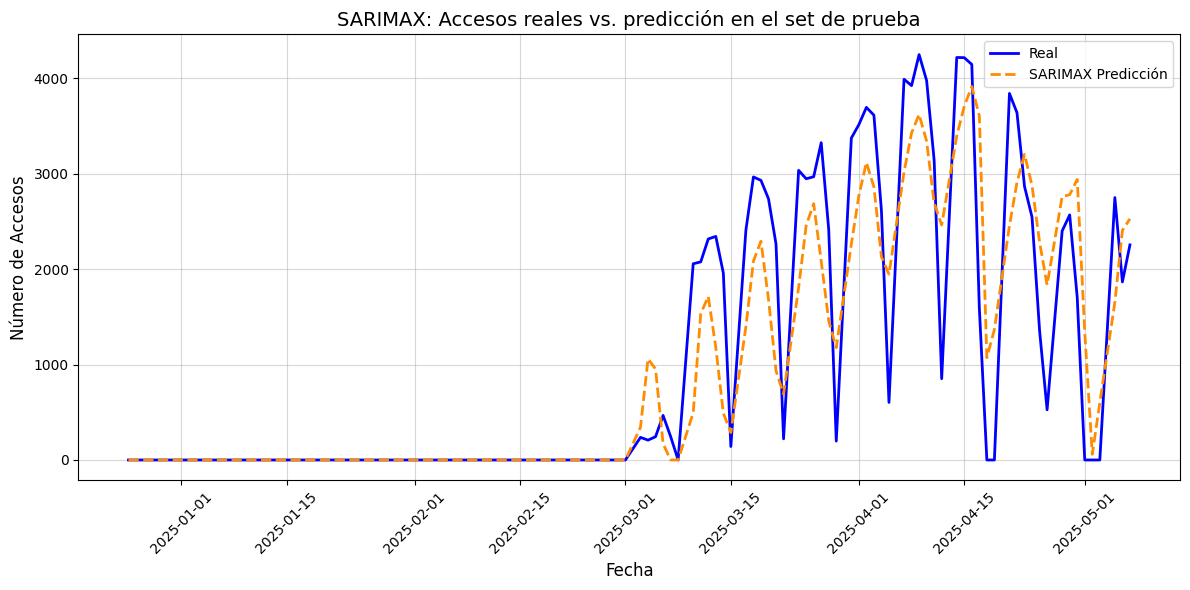


Se ha generado la visualización de la predicción de SARIMAX.


In [9]:
# --- 5. Visualización ---

# Graficar resultados de la predicción
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Real', color='blue', linewidth=2)
plt.plot(y_test.index, sarimax_predicted, label='SARIMAX Predicción', color='darkorange', linestyle='--', linewidth=2)
plt.title('SARIMAX: Accesos reales vs. predicción en el set de prueba', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de Accesos', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show() # 

print("\nSe ha generado la visualización de la predicción de SARIMAX.")